In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
df = pd.read_csv("sample_data/mnist_train_small.csv")
df_test = pd.read_csv("sample_data/mnist_test.csv")

In [3]:
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(19999, 785)

In [5]:
df.columns

Index(['6', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.581', '0.582', '0.583', '0.584', '0.585', '0.586', '0.587', '0.588',
       '0.589', '0.590'],
      dtype='object', length=785)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Columns: 785 entries, 6 to 0.590
dtypes: int64(785)
memory usage: 119.8 MB


In [7]:
df.isnull().sum()

,0
6,0
0,0
0.1,0
0.2,0
0.3,0
...,...
0.586,0
0.587,0
0.588,0
0.589,0


In [8]:
df = pd.read_csv("sample_data/mnist_train_small.csv")
df = df.dropna()

In [9]:
df.isnull().sum()

,0
6,0
0,0
0.1,0
0.2,0
0.3,0
...,...
0.586,0
0.587,0
0.588,0
0.589,0


In [10]:
X_train = df.iloc[:, 1:].values
y_train = df.iloc[:, 0].values
X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

In [11]:
X_train= X_train.astype("float32")/255.0
X_test= X_test.astype("float32")/255.0

In [12]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [13]:
y_train_cat= to_categorical(y_train,10)
y_test_cat= to_categorical(y_test,10)

In [14]:
Perceptron= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
])

In [15]:
Perceptron.compile(optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"])

In [16]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(X_train_img.shape[0])
print(y_train_cat.shape[0])

print(X_test_img.shape[0])
print(y_test_cat.shape[0])

19999
19999
9999
9999


In [17]:
history_perceptron = Perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7297 - loss: 1.1436 - val_accuracy: 0.8408 - val_loss: 0.7165
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8500 - loss: 0.6354 - val_accuracy: 0.8677 - val_loss: 0.5495
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8693 - loss: 0.5284 - val_accuracy: 0.8807 - val_loss: 0.4818
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8776 - loss: 0.4766 - val_accuracy: 0.8866 - val_loss: 0.4447
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8836 - loss: 0.4449 - val_accuracy: 0.8910 - val_loss: 0.4201
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8876 - loss: 0.4226 - val_accuracy: 0.8937 - val_loss: 0.4029
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8912 - loss: 0.4059 - val_accuracy: 0.8978 - val_loss: 0.3890
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8937 - loss: 0.3930 - val_accuracy: 0.

In [18]:
acc_perceptron= Perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]
print("Accuracy of Perceptron:",acc_perceptron)

Accuracy of Perceptron: 0.9020901918411255


In [19]:
#ANN
ann= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [20]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [21]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8849 - loss: 0.3963 - val_accuracy: 0.9407 - val_loss: 0.2121
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9520 - loss: 0.1652 - val_accuracy: 0.9536 - val_loss: 0.1577
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9658 - loss: 0.1126 - val_accuracy: 0.9609 - val_loss: 0.1326
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0768 - val_accuracy: 0.9586 - val_loss: 0.1333
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9818 - loss: 0.0581 - val_accuracy: 0.9620 - val_loss: 0.1369
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0444 - val_accuracy: 0.9621 - val_loss: 0.1299
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.9670 - val_loss: 0.1225
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0283 - val_accuracy: 0.

In [22]:
acc_ann= ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [23]:
acc_ann

0.9673967361450195

### 1. Reshape the Data for CNN
CNN layers like `Conv2D` expect inputs to have a channel dimension (height, width, channels). Since MNIST contains grayscale images, we reshape our images from `(28, 28)` to `(28, 28, 1)`.

In [24]:
X_train_cnn = X_train_img.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_img.reshape(-1, 28, 28, 1)

print("Train shape for CNN:", X_train_cnn.shape)
print("Test shape for CNN:", X_test_cnn.shape)

Train shape for CNN: (19999, 28, 28, 1)
Test shape for CNN: (9999, 28, 28, 1)


### 2. Build the CNN Model
We will define a `Sequential` model with Convolutional (`Conv2D`), Max Pooling (`MaxPool2D`), and Dropout layers, ending with Dense layers for classification.

In [25]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compile and Train the CNN

In [26]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8606 - loss: 0.4374 - val_accuracy: 0.9723 - val_loss: 0.0919
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9532 - loss: 0.1550 - val_accuracy: 0.9800 - val_loss: 0.0641
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9636 - loss: 0.1186 - val_accuracy: 0.9821 - val_loss: 0.0556
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9713 - loss: 0.0947 - val_accuracy: 0.9813 - val_loss: 0.0552
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9732 - loss: 0.0865 - val_accuracy: 0.9859 - val_loss: 0.0434
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9771 - loss: 0.0741 - val_accuracy: 0.9863 - val_loss: 0.0425
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9794 - loss: 0.0644 - val_accuracy: 0.9860 - val_loss: 0.0396
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9821 - loss: 0.0562 - val_accuracy: 

### 4. Evaluate the CNN Model

In [27]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
print(f"Accuracy of CNN: {acc_cnn:.4f}")

Accuracy of CNN: 0.9872


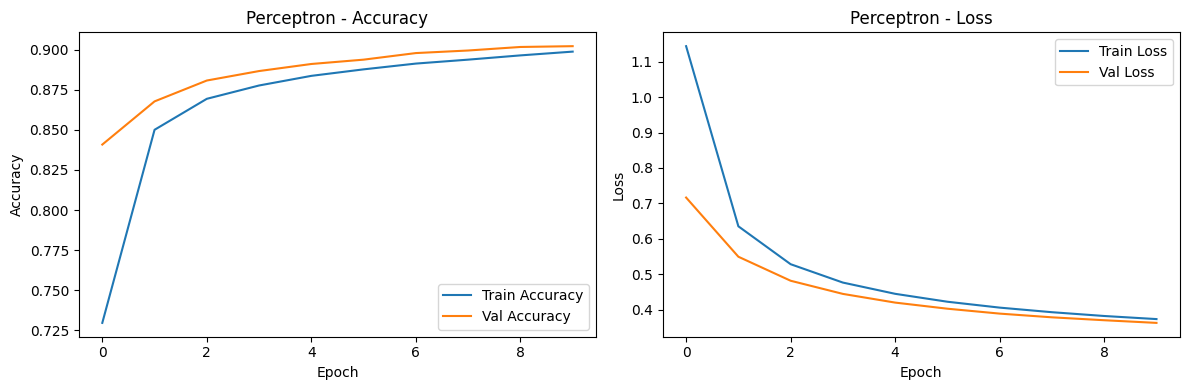

In [28]:
import matplotlib.pyplot as plt

def plot_training(history, title="Model Performance"):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function with your actual history object
plot_training(history_perceptron, title="Perceptron")

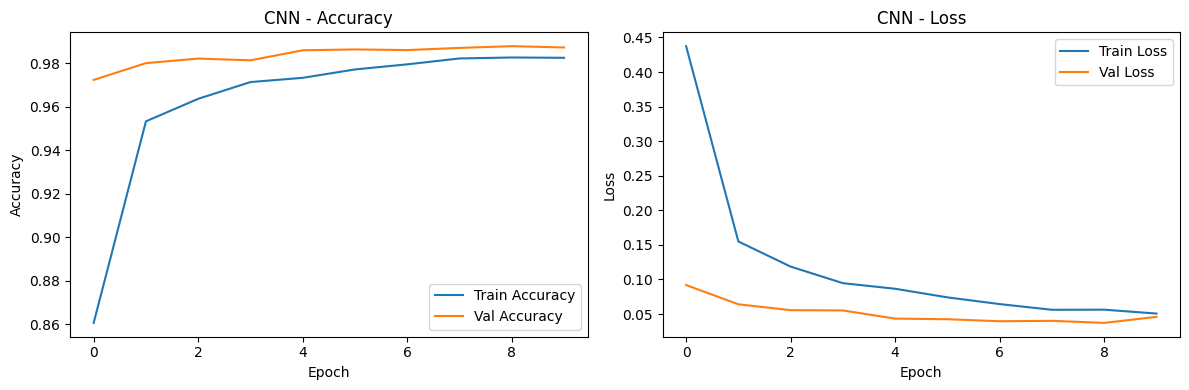

In [29]:
import matplotlib.pyplot as plt

def plot_training(history, title="Model Performance"):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function with your actual history object
plot_training(history_cnn, title="CNN")

### 5. Compare All Three Models
Now, let's consolidate the validation accuracies of our three models (Perceptron, ANN, and CNN) and plot them to clearly visualize which model performs the best on the MNIST test dataset.

,Model,Accuracy
0,Perceptron,0.902090
1,ANN,0.967397
2,CNN,0.987199


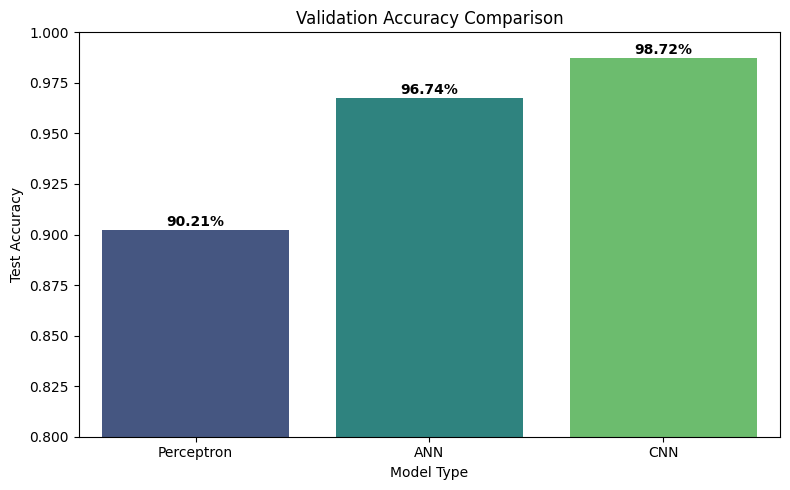

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather accuracies
models = ['Perceptron', 'ANN', 'CNN']
accuracies = [acc_perceptron, acc_ann, acc_cnn]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

display(comparison_df)

# Plot the comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.ylim(0.8, 1.0)  # Zoom in on the top performing range
plt.title('Validation Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xlabel('Model Type')

# Annotate the exact values on top of the bars
for index, row in comparison_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.002, f"{row['Accuracy']*100:.2f}%", color='black', ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

### Comparison Insights:
* **Perceptron (~90.05%)**: Serves as our baseline single-layer model. While fast to train, it struggles to capture the complex spatial relationships of the image pixels.
* **ANN (~96.52%)**: Adding multiple dense (fully-connected) hidden layers allows the network to learn non-linear representations, boosting accuracy significantly.
* **CNN (~98.68%)**: The top-performing model. By leveraging spatial hierarchy through convolutions and pooling, it extracts local patterns (edges, shapes) natively from the 2D pixel structure, achieving near-perfect classification.

### 6. Visualize Sample Predictions from the CNN Model
Let's pick a few random images from the test dataset, pass them to our trained CNN model, and compare the model's predictions against the true labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step


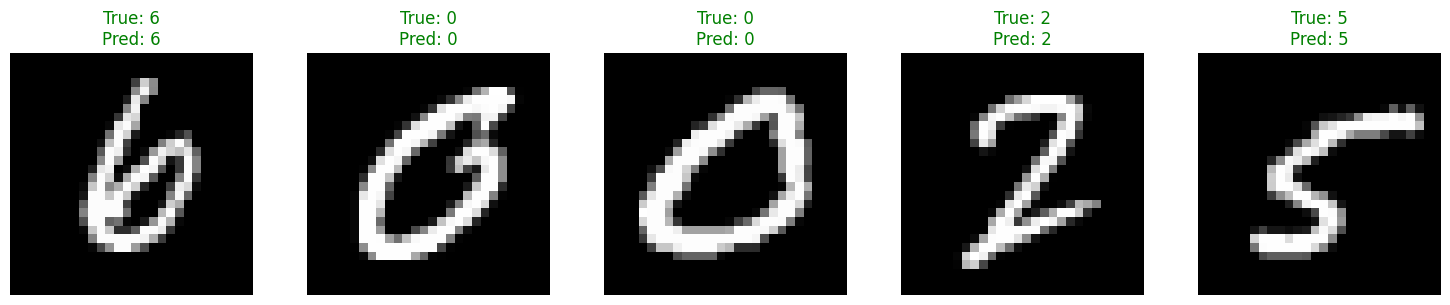

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Choose 5 random indices from the test set
random_indices = np.random.choice(len(X_test_img), size=5, replace=False)

# Get predictions for these samples
sample_images = X_test_cnn[random_indices]
predictions = cnn.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test[random_indices]

# Plot the results
plt.figure(figsize=(15, 3))
for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_img[idx], cmap='gray')

    # Color green if correct, red if incorrect
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'

    plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 7. Add an Interactive Web UI (Gradio) for Deployment
To showcase this project on your resume and GitHub, we will create an interactive Web App using **Gradio**. This allows anyone to draw digits directly on a canvas and get real-time predictions from your CNN model. We will install Gradio, build the interface, and launch it with a public link.

In [32]:
!pip install -q gradio

In [33]:
import gradio as gr
import numpy as np
import tensorflow as tf

def predict_digit(image_dict):
    # Gradio Sketchpad returns a dictionary containing a composite 'composite' image or 'layers'
    # We extract the drawn pixel image matrix
    img = image_dict['composite']

    if img is None:
        return "No image drawn."

    # Convert image to grayscale (MNIST format)
    if len(img.shape) == 3:
        # Take the alpha channel or convert RGB to Grayscale
        # Gradio sketchpad drawing is typically white ink on a black background, or in the alpha channel
        img_gray = img[:, :, 3] if img.shape[2] == 4 else np.mean(img, axis=2)
    else:
        img_gray = img

    # Resize the image to 28x28 pixels as required by our MNIST models
    # We use temporary pillow image conversion to safely resize
    from PIL import Image
    pil_img = Image.fromarray(img_gray.astype('uint8')).resize((28, 28))
    img_resized = np.array(pil_img)

    # Normalize the pixel values
    img_normalized = img_resized.astype('float32') / 255.0

    # Reshape to match the input shape of the CNN: (1, 28, 28, 1)
    input_data = img_normalized.reshape(1, 28, 28, 1)

    # Predict using the trained CNN model
    prediction = cnn.predict(input_data)[0]
    predicted_class = int(np.argmax(prediction))
    confidence = float(prediction[predicted_class])

    # Prepare clean dictionary of probabilities for all classes
    return {str(i): float(prediction[i]) for i in range(10)}

# Design and Launch the Gradio Interface
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(label="Draw a Digit (0-9)", type="numpy"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    title="Handwritten Digit Classifier",
    description="Draw a digit between 0 and 9 in the box below and watch the CNN model classify it in real-time!",
    theme="huggingface"
)

# Launch with share=True to get a public link for your portfolio!
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://41e91461758901ddf0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 🚀 How to deploy this on your GitHub and Resume:

1. **Publish to Hugging Face Spaces (Highly Recommended):**
   * Go to [Hugging Face Spaces](https://huggingface.co/spaces) and create a free account.
   * Click **Create new Space**, select **Gradio** as the SDK, and name your repository.
   * Upload your trained model (e.g., save it first using `cnn.save('mnist_cnn.keras')`) and write an `app.py` script containing your Gradio interface structure.
   * Hugging Face will host your app on their servers for free, giving you a permanent web link.

2. **Incorporate into GitHub & Resume:**
   * Embed your live Hugging Face app link directly into your GitHub repository's `README.md` file using an iframe or a badges layout.
   * Add a section under your Resume's Project experience: **"Handwritten Digit Classifier App - [Live App Link] | [GitHub Repo Link]"**.